# Módulo 4: Stop-Loss Agregado

## ¿Qué es?

El reasegurador cubre el exceso de la **pérdida agregada total** $S$
que supere el deducible agregado $D$, hasta un límite $C$.

$$S^{\text{cedido}} = \min\big((S-D)_+,\ C\big)$$
$$S^{\text{retenido}} = S - S^{\text{cedido}}$$

A diferencia del XL que opera siniestro por siniestro,
el Stop-Loss opera sobre el total del año.

Usamos $D = 150,000$ y $C = 300,000$.

In [26]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.treaties import apply_stop_loss

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Cargar datos simulados
df          = pd.read_csv("../data/simulated_losses.csv")
S_pareto    = df["S_pareto"].values
S_lognormal = df["S_lognormal"].values

print(f"Escenarios cargados : {len(S_pareto):,}")
print(f"Media Pareto        : {S_pareto.mean():,.2f}")

Escenarios cargados : 100,000
Media Pareto        : 149,069.14


## Aplicando el Stop-Loss

Aplicamos $D = 150,000$ y $C = 300,000$ sobre la pérdida agregada.
El reasegurador entra solo cuando el año es peor que el promedio.

In [27]:
# Aplicar Stop-Loss
resultado_pareto = apply_stop_loss(S_pareto, D=150_000.0, C=300_000.0)

ret_pareto = resultado_pareto["retained"]
ced_pareto = resultado_pareto["ceded"]

print(f"{'Métrica':<20} {'Bruto':>15} {'Retenido SL':>15}")
print("=" * 52)
print(f"{'Media':<20} {S_pareto.mean():>15,.2f} {ret_pareto.mean():>15,.2f}")
print(f"{'Desv. estándar':<20} {S_pareto.std():>15,.2f} {ret_pareto.std():>15,.2f}")
print(f"{'VaR 99%':<20} {np.percentile(S_pareto,99):>15,.2f} {np.percentile(ret_pareto,99):>15,.2f}")
print(f"{'CVaR 99%':<20} {S_pareto[S_pareto >= np.percentile(S_pareto,99)].mean():>15,.2f} {ret_pareto[ret_pareto >= np.percentile(ret_pareto,99)].mean():>15,.2f}")
print(f"{'Máximo':<20} {S_pareto.max():>15,.2f} {ret_pareto.max():>15,.2f}")

Métrica                        Bruto     Retenido SL
Media                     149,069.14      132,185.18
Desv. estándar            204,664.09      190,559.63
VaR 99%                   437,966.07      150,000.00
CVaR 99%                  943,990.34      165,499.24
Máximo                 40,184,892.30   39,884,892.30


In [28]:
# Comparar distintos valores de C
resultados = {}
for C in [300_000, 1_000_000, 5_000_000, 10_000_000]:
    res = apply_stop_loss(S_pareto, D=150_000.0, C=float(C))
    resultados[f"SL C={C:,}"] = res["retained"]

print(f"{'Tratado':<20} {'Media':>12} {'Desv.Std':>12} {'VaR 99%':>12} {'Máximo':>15}")
print("=" * 75)
print(f"{'Bruto':<20} {S_pareto.mean():>12,.0f} {S_pareto.std():>12,.0f} {np.percentile(S_pareto,99):>12,.0f} {S_pareto.max():>15,.0f}")
for nombre, ret in resultados.items():
    print(f"{nombre:<20} {ret.mean():>12,.0f} {ret.std():>12,.0f} {np.percentile(ret,99):>12,.0f} {ret.max():>15,.0f}")

Tratado                     Media     Desv.Std      VaR 99%          Máximo
Bruto                     149,069      204,664      437,966      40,184,892
SL C=300,000              132,185      190,560      150,000      39,884,892
SL C=1,000,000            129,643      177,768      150,000      39,184,892
SL C=5,000,000            128,144      144,454      150,000      35,184,892
SL C=10,000,000           127,884      114,760      150,000      30,184,892


In [29]:
# Aplicar Stop-Loss con parámetros actualizados
resultado_pareto = apply_stop_loss(S_pareto, D=150_000.0, C=5_000_000.0)

ret_pareto = resultado_pareto["retained"]
ced_pareto = resultado_pareto["ceded"]

print(f"Parámetros: D = 150,000 | C = 5,000,000")
print(f"Capa cubre de 150K a 5.15M")
print()
print(f"{'Métrica':<20} {'Bruto':>15} {'Retenido SL':>15}")
print("=" * 52)
print(f"{'Media':<20} {S_pareto.mean():>15,.2f} {ret_pareto.mean():>15,.2f}")
print(f"{'Desv. estándar':<20} {S_pareto.std():>15,.2f} {ret_pareto.std():>15,.2f}")
print(f"{'VaR 99%':<20} {np.percentile(S_pareto,99):>15,.2f} {np.percentile(ret_pareto,99):>15,.2f}")
print(f"{'CVaR 99%':<20} {S_pareto[S_pareto >= np.percentile(S_pareto,99)].mean():>15,.2f} {ret_pareto[ret_pareto >= np.percentile(ret_pareto,99)].mean():>15,.2f}")
print(f"{'Máximo':<20} {S_pareto.max():>15,.2f} {ret_pareto.max():>15,.2f}")

Parámetros: D = 150,000 | C = 5,000,000
Capa cubre de 150K a 5.15M

Métrica                        Bruto     Retenido SL
Media                     149,069.14      128,144.23
Desv. estándar            204,664.09      144,454.26
VaR 99%                   437,966.07      150,000.00
CVaR 99%                  943,990.34      152,830.90
Máximo                 40,184,892.30   35,184,892.30


## Visualización: Bruto vs Retenido (Stop-Loss)

El Stop-Loss corta la distribución en una capa agregada.
Los años típicos no cambian, los años malos sí.

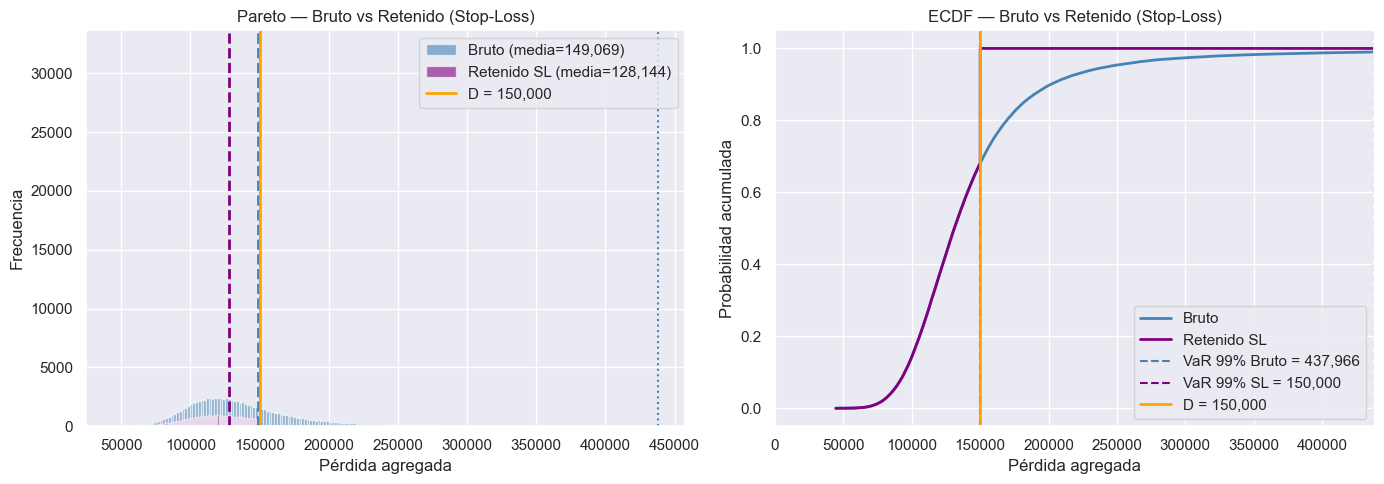

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_bruto    = np.percentile(S_pareto, 99)
p99_retenido = np.percentile(ret_pareto, 99)
x_max        = p99_bruto

# --- Gráfica 1: Histograma ---
axes[0].hist(S_pareto[S_pareto <= x_max], bins=200, alpha=0.6,
             color="steelblue", label=f"Bruto (media={S_pareto.mean():,.0f})")
axes[0].hist(ret_pareto[ret_pareto <= x_max], bins=200, alpha=0.6,
             color="purple", label=f"Retenido SL (media={ret_pareto.mean():,.0f})")
axes[0].axvline(S_pareto.mean(),    color="steelblue", linewidth=2, linestyle="--")
axes[0].axvline(ret_pareto.mean(),  color="purple",    linewidth=2, linestyle="--")
axes[0].axvline(p99_bruto,          color="steelblue", linewidth=1.5, linestyle=":")
axes[0].axvline(p99_retenido,       color="purple",    linewidth=1.5, linestyle=":")
axes[0].axvline(150_000, color="orange", linewidth=2, linestyle="-", label="D = 150,000")
axes[0].set_title("Pareto — Bruto vs Retenido (Stop-Loss)")
axes[0].set_xlabel("Pérdida agregada")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Gráfica 2: ECDF ---
S_sorted   = np.sort(S_pareto)
ret_sorted = np.sort(ret_pareto)
prob       = np.arange(1, len(S_sorted) + 1) / len(S_sorted)

axes[1].plot(S_sorted,   prob, color="steelblue", linewidth=2, label="Bruto")
axes[1].plot(ret_sorted, prob, color="purple",    linewidth=2, label="Retenido SL")
axes[1].axvline(p99_bruto,    color="steelblue", linewidth=1.5, linestyle="--",
                label=f"VaR 99% Bruto = {p99_bruto:,.0f}")
axes[1].axvline(p99_retenido, color="purple",    linewidth=1.5, linestyle="--",
                label=f"VaR 99% SL = {p99_retenido:,.0f}")
axes[1].axvline(150_000, color="orange", linewidth=2, linestyle="-", label="D = 150,000")
axes[1].set_xlim(0, x_max)
axes[1].set_title("ECDF — Bruto vs Retenido (Stop-Loss)")
axes[1].set_xlabel("Pérdida agregada")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/05_stop_loss_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen final de métricas — Los tres tratados

Comparamos las métricas actuariales de los cuatro escenarios:
bruto, Cuota Parte, Excess of Loss y Stop-Loss.

In [31]:
def resumen_metricas(S, nombre):
    var99  = np.percentile(S, 99)
    cvar99 = S[S >= var99].mean()
    media  = S.mean()
    std    = S.std()
    prima  = media + 1.5 * std
    return {
        "Tratado"        : nombre,
        "Media"          : media,
        "Desv. Estándar" : std,
        "VaR 99%"        : var99,
        "CVaR 99%"       : cvar99,
        "Prima Técnica"  : prima,
    }

# Retenido Quota Share
ret_qs = S_pareto * 0.60

# Retenido XL (resimular)
rng = np.random.default_rng(42)
N   = rng.poisson(lam=50.0, size=100_000)
S_xl_retenido = np.zeros(100_000)
for i, n in enumerate(N):
    if n == 0:
        continue
    U = rng.uniform(size=n)
    Y = 1_000.0 / (U ** (1.0 / 1.5))
    from src.treaties import apply_excess_of_loss
    res = apply_excess_of_loss(Y, M=100_000.0, L=400_000.0)
    S_xl_retenido[i] = res["retained"].sum()

# Tabla comparativa
metricas = pd.DataFrame([
    resumen_metricas(S_pareto,      "Bruto"),
    resumen_metricas(ret_qs,        "Quota Share"),
    resumen_metricas(S_xl_retenido, "Excess of Loss"),
    resumen_metricas(ret_pareto,    "Stop-Loss"),
])

metricas.set_index("Tratado", inplace=True)
print(metricas.map(lambda x: f"{x:,.2f}"))

                     Media Desv. Estándar     VaR 99%    CVaR 99%  \
Tratado                                                             
Bruto           149,069.14     204,664.09  437,966.07  943,990.34   
Quota Share      89,441.49     122,798.45  262,779.64  566,394.20   
Excess of Loss  139,919.83      43,009.30  276,153.70  308,078.07   
Stop-Loss       128,144.23     144,454.26  150,000.00  152,830.90   

               Prima Técnica  
Tratado                       
Bruto             456,065.27  
Quota Share       273,639.16  
Excess of Loss    204,433.77  
Stop-Loss         344,825.62  
